<table>
    <tr>
        <td><img src="./img/Macc.png" width="auto"/></td>
        <td>
            <table><tr>
            <h1 style="color:blue;text-align:center">Lógica para Ciencias de la Computación</h1></td>
            </tr></table>   
        <td>&nbsp;</td>
        <td>
            <table><tr>
            <tp><p style="font-size:150%;text-align:center">Entrega Final</p></tp>
            <tp><p style="font-size:150%;text-align:center">Nanograma 5x5</p></tp>
            </tr></table>
        </td>
    </tr>
</table>

---

# Objetivo <a class="anchor" id="inicio"></a>

El siguiente problema se puede definir como una cuadricula de tamaño n x n en la cual en cada columna y fila están indicados una secuencia de números o un numero solo. Es decir, existen dos casos el primero si es un numero solo indica el número exacto de casillas que deben ser rellenadas en esa fila y columna. El otro caso una secuencia de números en el que el primer elemento es la cantidad de cuadro seguidos posibles a rellenar hasta un espacio y así con todos los elementos de la secuencia.

Se usará una cuadricula de tamaño 5x5, con cualquiera de los posibles casos .

<img src="./img/emptynanogram.png" width="auto"/>




Desarrollaremos la presentación de la siguiente manera:


# Secciones

1. [Problema ilustrativo.](#prob)
2. [Implementación de las restricciones.](#forms)
3. [Visualización.](#vis)
4. [Solución mediante SATtabla.](#sat)


# Problema de ejemplo <a class="anchor" id="prob"></a>

([Volver al inicio](#inicio))

Comenzaremos con el problema presentado en las diapositivas de clase, que repetimos aquí por conveniencia:


<img src="./img/figura2.png" width="200px"/>
<img src="./img/regla2-2.png" width="200px"/>



Las restricciones y su representación usando lógica proposicional son las siguientes:

1. Debe haber exactamente dos casillas rellenas consecutivas en la primera fila de la cuadricula:


$\bigvee\limits_{i=0}^3  \Bigg[Ren_{(0, i)} \land Ren_{(0, i+1)} \bigwedge\limits_{j=o, j\neq i,i+1}^4 \Bigg(\neg{Ren_{(0, j)}}\Bigg)\Bigg] $ 

2. Debe haber dos casillas rellenas consecutivas luego minimo un espacio la primera columna de la cuadricula:

24.$\neg{Ren_{(2,n)}} \bigwedge\limits_{j=0, j \neq 2}^4 \Bigg( Ren_{(j,n)} \Bigg)$




# Creacion las restricciones <a class="anchor" id="prob"></a>

([Volver al inicio](#inicio))

Gracias al ejemplo anterior se puede evidenciar que cada fila y columna tendra su propias restricciones según el numero indicado en la parte superior. Como vamos a generalizar la resolucion de todos los casos implementamos todas las posibles restricciones en el código pero para resolver el Nanograma solo se tomaran las 10 necesarias con el metodo clasificador_reglas







In [3]:
    
def clasificador_reglas(self):
        
        # Este metodo esta encargado de elegir las 10 reglas que se van a necesitar para resolver el nanograma
        # Dadas las condiciones iniciales
        
        
        # Al iniciar         self.reglas = []
        # finalizando este ciclo self.reglas tendra 10 reglas las cuales son la Ytoria de la solucion
    for x in self.condiciones_iniciales.keys(): 
            # Si la condicion es un numero solo va a hacer append de la regla a self.reglas dependiendo del numero que es la condicion inicial
            # Para esa fila y/o columna
        try:
            funciones_regla = {0: self.regla1, 1: self.regla2, 2: self.regla3,3: self.regla4, 4: self.regla5, 5: self.regla6}
            valor_condicion = self.condiciones_iniciales[x]
            if valor_condicion in funciones_regla:
                self.reglas.append(funciones_regla[valor_condicion](x))

        except TypeError: 
                
                # Si la condicion es una secuencia de numeros solo va a hacer append de la regla dependiendo del numero que es la condicion inicial
                # Para esa fila y/o columna
                
                
                
            if self.condiciones_iniciales[x] == [1,1]: self.reglas.append(self.regla7(x))
            elif self.condiciones_iniciales[x] == [1,2]: self.reglas.append(self.regla8(x))
            elif self.condiciones_iniciales[x] == [1,3]: self.reglas.append(self.regla9(x))
                
            elif self.condiciones_iniciales[x] == [2,1]: self.reglas.append(self.regla10(x))
            elif self.condiciones_iniciales[x] == [2,2]: self.reglas.append(self.regla11(x))
                
            elif self.condiciones_iniciales[x] == [3,1]: self.reglas.append(self.regla12(x))
                
            elif self.condiciones_iniciales[x] == [1,1,1]: self.reglas.append(self.regla13(x))

## Implementación de las restricciones <a class="anchor" id="forms"></a>

([Volver al inicio](#inicio))

En la librería `EntregaFinal` hemos implementado veintiseis posibles  reglas. Puede correr el siguiente código para visualizar el resultado, y puede entrar a la librería para explorar la implementación, luego de que la fuuncion clasificador de formulas se aplica sobre el obejto nanograma:

{0: [2, 1], 1: 3, 2: 4, 3: [1, 3], 4: 0, 5: [1, 1], 6: 3, 7: 3, 8: 3, 9: [1, 2]}
(((((((((((((((La casilla (0,0)  esta rellena Y La casilla (0,1)  esta rellena) Y La casilla (0,3)  esta rellena) Y  no La casilla (0,2)  esta rellena) Y  no La casilla (0,4)  esta rellena) O ((((La casilla (0,0)  esta rellena Y La casilla (0,1)  esta rellena) Y La casilla (0,4)  esta rellena) Y  no La casilla (0,2)  esta rellena) Y  no La casilla (0,3)  esta rellena)) O ((((La casilla (0,1)  esta rellena Y La casilla (0,2)  esta rellena) Y La casilla (0,4)  esta rellena) Y  no La casilla (0,0)  esta rellena) Y  no La casilla (0,3)  esta rellena)) Y ((((((La casilla (1,0)  esta rellena Y La casilla (1,1)  esta rellena) Y La casilla (1,2)  esta rellena) Y  no La casilla (1,3)  esta rellena) Y  no La casilla (1,4)  esta rellena) O ((((La casilla (1,1)  esta rellena Y La casilla (1,2)  esta rellena) Y La casilla (1,3)  esta rellena) Y  no La casilla (1,0)  esta rellena) Y  no La casilla (1,4)  esta rellena)) 

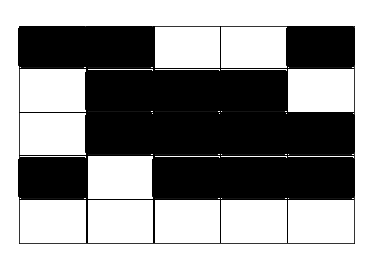

--- 0.290006160736084 seconds ---


In [4]:
from Logica import *
from EntregaFinal import Nanograma

### Cuando se crea el objeto Nanograma ya estan definidas las condiciones iniciales para que al llamar al metodo escoja las 10 reglas de acuerdo a las condiciones iniciales dadas
## las condiciones inciales se crearon en un atributo del objeto que consiste en un diccionario donde la llave indica la fila o columna y el valor la condicion de la misma
# 
# suponga self. condiciones iniciales = {0: [2, 1], 1: 3, 2: 4, 3: [1, 3], 4: 0, 5: [1, 1], 6: 3, 7: 3, 8: 3, 9: [1, 2]}
# 
# la condicion de la fila 0 -> [2,1] , fila 1 -> 3, ..... , columna 0 -> [1,1], .... , columna 4 -> [1,2]

c = Nanograma()

# el metodo clasificador_reglas toma las condiciones iniciales y por cada condicion agrega la regla correspondiente a self.reglas  
# self.reglas al principio es una lista vacia que luego se le van añadiendo las reglas segun las restricciones que requiera el problema 
c.clasificador_reglas()

Observe que ahora el objeto tiene un atributo `reglas`, en el cual está una lista con las diez reglas implementadas en Python:

In [5]:
c.reglas

['((((((ĀYą)Yď)Y-Ċ)Y-Ĕ)O((((ĀYą)YĔ)Y-Ċ)Y-ď))O((((ąYĊ)YĔ)Y-Ā)Y-ď))',
 '((((((āYĆ)Yċ)Y-Đ)Y-ĕ)O((((ĆYċ)YĐ)Y-ā)Y-ĕ))O((((ċYĐ)Yĕ)Y-ā)Y-Ć))',
 '(((((ĂYć)YČ)Yđ)Y-Ė)O((((ćYČ)Yđ)YĖ)Y-Ă))',
 '((((ăYč)YĒ)Yė)Y-Ĉ)',
 '((((-ĄY-ĉ)Y-Ď)Y-ē)Y-Ę)',
 '(((((((((ĀYĂ)Y-ā)Y-ă)Y-Ą)O((((ĀYă)Y-ā)Y-Ă)Y-Ą))O((((ĀYĄ)Y-ā)Y-Ă)Y-ă))O((((āYă)Y-Ā)Y-Ă)Y-Ą))O((((āYĄ)Y-Ā)Y-Ă)Y-ă))O((((ĂYĄ)Y-Ā)Y-ā)Y-ă))',
 '((((((ąYĆ)Yć)Y-Ĉ)Y-ĉ)O((((ĆYć)YĈ)Y-ą)Y-ĉ))O((((ćYĈ)Yĉ)Y-ą)Y-Ć))',
 '((((((ĊYċ)YČ)Y-č)Y-Ď)O((((ċYČ)Yč)Y-Ċ)Y-Ď))O((((ČYč)YĎ)Y-Ċ)Y-ċ))',
 '((((((ďYĐ)Yđ)Y-Ē)Y-ē)O((((ĐYđ)YĒ)Y-ď)Y-ē))O((((đYĒ)Yē)Y-ď)Y-Đ))',
 '((((((ĔYĖ)Yė)Y-ĕ)Y-Ę)O((((ĔYė)YĘ)Y-ĕ)Y-Ė))O((((ĕYė)YĘ)Y-Ĕ)Y-Ė))']

La clase `Nanograma` crea de una vez el descriptor, mediante el cual podemos decodificar las letras y reglas:

In [6]:
c.RenC.escribir('ć')

'La casilla (2,1)  esta rellena'

También podemos revisar regla por regla. Observe que las fórmulas incluyen un método `ver` para visualizar más fácilmente las reglas:

In [7]:
A = inorder_to_tree(c.reglas[1])
print(A.ver(c.RenC))

((((((La casilla (1,0)  esta rellena Y La casilla (1,1)  esta rellena) Y La casilla (1,2)  esta rellena) Y  no La casilla (1,3)  esta rellena) Y  no La casilla (1,4)  esta rellena) O ((((La casilla (1,1)  esta rellena Y La casilla (1,2)  esta rellena) Y La casilla (1,3)  esta rellena) Y  no La casilla (1,0)  esta rellena) Y  no La casilla (1,4)  esta rellena)) O ((((La casilla (1,2)  esta rellena Y La casilla (1,3)  esta rellena) Y La casilla (1,4)  esta rellena) Y  no La casilla (1,0)  esta rellena) Y  no La casilla (1,1)  esta rellena))


In [6]:
A = inorder_to_tree(c.reglas[0])
print(A.ver(c.RenC))

((((((La casilla (0,0)  esta rellena Y La casilla (0,1)  esta rellena) Y La casilla (0,3)  esta rellena) Y  no La casilla (0,2)  esta rellena) Y  no La casilla (0,4)  esta rellena) O ((((La casilla (0,0)  esta rellena Y La casilla (0,1)  esta rellena) Y La casilla (0,4)  esta rellena) Y  no La casilla (0,2)  esta rellena) Y  no La casilla (0,3)  esta rellena)) O ((((La casilla (0,1)  esta rellena Y La casilla (0,2)  esta rellena) Y La casilla (0,4)  esta rellena) Y  no La casilla (0,0)  esta rellena) Y  no La casilla (0,3)  esta rellena))


## Visualización <a class="anchor" id="vis"></a>

([Volver al inicio](#inicio))

Una parte muy importante de la clase `Nanograma` es el método que permite visualizar el tablero, dada una interpretación de las reglas proposicionales. Esto es lo que nos permite entender la solución del problema.

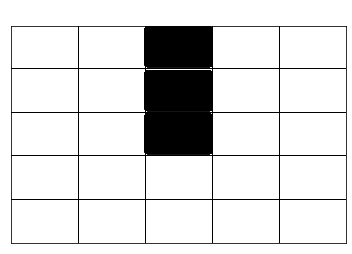

In [8]:
I = {c.RenC.P([0,2]):True, c.RenC.P([1,2]):True, c.RenC.P([2,2]):True}
c.visualizar(I)

## Solución mediante SATsolvers <a class="anchor" id="sat"></a>

([Volver al inicio](#inicio))

Ahora podemos ver el corazón de la solución a este y todos los demas problemas que desarrollemos: un SATsolver. Usaremos el SATtabla que implementamos anteriormente.

In [9]:
%%time
A = inorder_to_tree(Ytoria(c.reglas))
I = A.SATtabla()

Wall time: 34.8 s


Podemos decodificar el diccionario `I` obtenido para ver la solución:

In [10]:
if I != None:
    for k in I:
        print(c.RenC.escribir(k), I[k])
else:
    print('¡No hay solución!')

La casilla (0,1)  esta rellena True
La casilla (1,3)  esta rellena True
La casilla (3,2)  esta rellena True
La casilla (2,4)  esta rellena True
La casilla (0,3)  esta rellena False
La casilla (1,4)  esta rellena False
La casilla (2,3)  esta rellena True
La casilla (4,3)  esta rellena False
La casilla (4,4)  esta rellena False
La casilla (3,4)  esta rellena True
La casilla (2,2)  esta rellena True
La casilla (1,0)  esta rellena False
La casilla (4,1)  esta rellena False
La casilla (0,4)  esta rellena True
La casilla (0,2)  esta rellena False
La casilla (3,3)  esta rellena True
La casilla (1,2)  esta rellena True
La casilla (4,0)  esta rellena False
La casilla (3,1)  esta rellena False
La casilla (4,2)  esta rellena False
La casilla (0,0)  esta rellena True
La casilla (3,0)  esta rellena True
La casilla (2,1)  esta rellena True
La casilla (2,0)  esta rellena False
La casilla (1,1)  esta rellena True


O, mejor aún, podemos visualizar la solución:

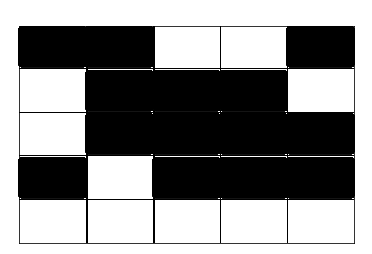

In [11]:
if I != None:
    c.visualizar(I)
else:
    print('¡No hay solución!')

Vemos que la solución encontrada por SATtabla es muy rápida.

Para los otros SATsolvers tenemos:


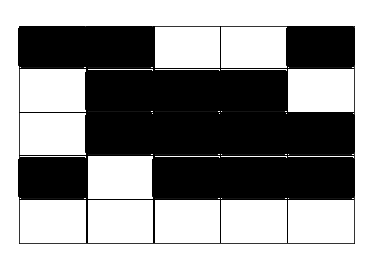

--- 0.23438048362731934 seconds ---


In [12]:


## DPLL
import time

start_time = time.time()

A = Ytoria(c.reglas)
S = tseitin(A)
S, I = dpll(S, {})


if I != None:
    for k in I:
        c.RenC.escribir(k), I[k]
            
        
else:
    print('¡No hay solución!')

c.visualizar(I)

print("--- %s seconds ---" % (time.time() - start_time))  


La casilla (4,4)  esta rellena False
La casilla (3,1)  esta rellena False
La casilla (4,3)  esta rellena False
La casilla (3,4)  esta rellena True
La casilla (4,2)  esta rellena False
La casilla (3,3)  esta rellena True
La casilla (4,0)  esta rellena False
La casilla (4,1)  esta rellena False
La casilla (3,0)  esta rellena True
La casilla (3,2)  esta rellena True
La casilla (2,4)  esta rellena False
La casilla (2,3)  esta rellena True
La casilla (2,2)  esta rellena True
La casilla (2,0)  esta rellena True
La casilla (2,1)  esta rellena True
La casilla (0,3)  esta rellena False
La casilla (0,0)  esta rellena False
La casilla (0,4)  esta rellena True
La casilla (0,1)  esta rellena True
La casilla (0,2)  esta rellena True
La casilla (1,1)  esta rellena False
La casilla (1,0)  esta rellena False
La casilla (1,4)  esta rellena True
La casilla (1,2)  esta rellena True
La casilla (1,3)  esta rellena True


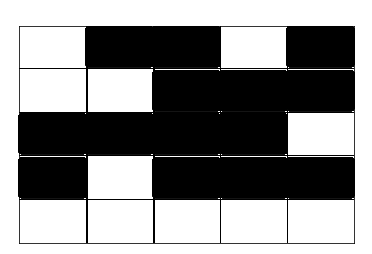

--- 0.2382357120513916 seconds ---


In [13]:
## SAT tableaux


start_time = time.time()

A = inorder_to_tree(Ytoria(c.reglas[0:5]))
I = A.SATtableaux()

if I != None:
     for k in I:
         print(c.RenC.escribir(k), I[k])
else:
     print('¡No hay solución!')
    
c.visualizar(I)

print("--- %s seconds ---" % (time.time() - start_time))  


La casilla (0,1)  esta rellena True
La casilla (1,3)  esta rellena True
La casilla (3,2)  esta rellena True
La casilla (2,4)  esta rellena True
La casilla (0,3)  esta rellena True
La casilla (1,4)  esta rellena True
La casilla (2,3)  esta rellena True
La casilla (4,3)  esta rellena False
La casilla (4,4)  esta rellena False
La casilla (3,4)  esta rellena True
La casilla (2,2)  esta rellena True
La casilla (1,0)  esta rellena False
La casilla (4,1)  esta rellena False
La casilla (0,4)  esta rellena False
La casilla (0,2)  esta rellena False
La casilla (3,3)  esta rellena True
La casilla (1,2)  esta rellena True
La casilla (4,0)  esta rellena False
La casilla (3,1)  esta rellena False
La casilla (4,2)  esta rellena False
La casilla (0,0)  esta rellena True
La casilla (3,0)  esta rellena True
La casilla (2,1)  esta rellena True
La casilla (2,0)  esta rellena False
La casilla (1,1)  esta rellena False


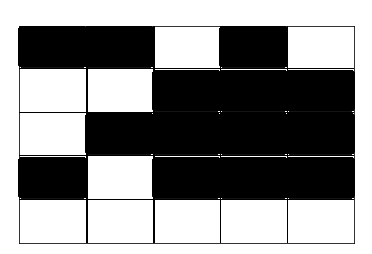

--- 15.240938663482666 seconds ---


In [14]:
## SAT tabla

start_time = time.time()

A = inorder_to_tree(Ytoria(c.reglas[0:5]))
I = A.SATtabla()


if I != None:
    for k in I:
        print(c.RenC.escribir(k), I[k])
else:
    print('¡No hay solución!')
    
c.visualizar(I)

print("--- %s seconds ---" % (time.time() - start_time))  


In [15]:

##WalkSAT

start_time = time.time()

A = Ytoria(c.reglas)
S = tseitin(A)
S, I = walkSAT(S)


if I != None:
    for k in I:
        print(c.RenC.escribir(k), I[k])
            
        
else:
    print('¡No hay solución!')

c.visualizar(I)


print("--- %s seconds ---" % (time.time() - start_time))  



KeyboardInterrupt: 

In [20]:
def minisat(S):
    I = {}
    sat, I = dpll(S, I)
    return sat, I

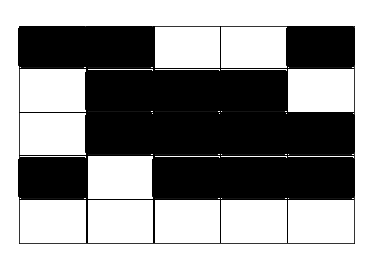

--- 0.24784350395202637 seconds ---


In [22]:
#MiniSAT 22

start_time = time.time()

A = Ytoria(c.reglas)
S = tseitin(A)
S, I = minisat(S)


if I != None:
    for k in I:
        c.RenC.escribir(k), I[k]
            
        
else:
    print('¡No hay solución!')

c.visualizar(I)

print("--- %s seconds ---" % (time.time() - start_time)) 

